In [19]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [20]:
import yfinance as yf

ticker = "GC=F"

gold_data = yf.download(ticker, start="2000-01-01", end=None, progress=False)

In [21]:
gold_data.reset_index(inplace=True)
gold_data.columns = [col[0] for col in gold_data.columns]

In [22]:
gold_data

,Date,Close,High,Low,Open,Volume
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0
1,2000-08-31,278.299988,278.299988,274.799988,274.799988,0
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0
...,...,...,...,...,...,...
6175,2025-04-11,3222.199951,3235.000000,3182.100098,3182.100098,862
6176,2025-04-14,3204.800049,3228.800049,3194.500000,3215.500000,263
6177,2025-04-15,3218.699951,3218.699951,3214.000000,3216.000000,390
6178,2025-04-16,3326.600098,3334.899902,3238.300049,3238.300049,1874


In [23]:
gold_data["Pct_Change"] = gold_data["Close"].pct_change()

In [24]:
gold_data = gold_data[1:]

In [25]:
gold_data.to_csv("YFinance_data.csv")

In [ ]:
cluster = pd.read_csv("cluster_embedding_output.csv")

In [27]:
cluster

,Dates,topic_china_fed_and_gold_focus,topic_comex_gold_closing_prices,topic_early_gold_trading_activity,topic_economic_data_and_gold_performance,topic_global_cues_and_gold_stability,topic_global_investment_and_rate_impact,topic_gold_climbs_in_trading,topic_gold_holds_as_data_releases,topic_gold_market_turning_points,topic_gold_near_monthly_lows,topic_gold_price_support_levels,topic_gold_prices_and_metal_shares,topic_gold_settlement_price_correction,topic_gold_spot_price_outlook,topic_gold_trading_momentum_continues,topic_market_rates_and_gold_demand,topic_rate_hikes/cuts_price_impact,topic_time_sensitive_prediction,topic_noise
0,2000-02-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2000-02-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2000-03-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2000-04-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2000-05-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3667,2019-01-25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3668,2019-01-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3669,2019-01-30,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3670,2019-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [28]:
cluster["Date"] = pd.to_datetime(cluster["Dates"])
gold_data["Date"] = pd.to_datetime(gold_data["Date"])

/var/folders/mc/2wjfdchj6vsffbrpfbfgqw4w0000gn/T/ipykernel_74474/3048298773.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gold_data["Date"] = pd.to_datetime(gold_data["Date"])


In [ ]:
merged_df = pd.merge(cluster, gold_data, left_on="Date", right_on="Date", how="inner")

In [30]:
merged_df

,Dates,topic_china_fed_and_gold_focus,topic_comex_gold_closing_prices,topic_early_gold_trading_activity,topic_economic_data_and_gold_performance,topic_global_cues_and_gold_stability,topic_global_investment_and_rate_impact,topic_gold_climbs_in_trading,topic_gold_holds_as_data_releases,topic_gold_market_turning_points,...,topic_rate_hikes/cuts_price_impact,topic_time_sensitive_prediction,topic_noise,Date,Close,High,Low,Open,Volume,Pct_Change
0,2000-09-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2000-09-07,274.000000,274.000000,274.000000,274.000000,125,-0.000729
1,2000-09-08,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2000-09-08,273.299988,273.299988,273.299988,273.299988,0,-0.002555
2,2000-09-14,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2000-09-14,272.399994,272.399994,272.399994,272.399994,0,-0.001466
3,2000-10-10,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2000-10-10,272.399994,272.399994,272.399994,272.399994,13,0.008515
4,2000-10-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,2000-10-16,271.500000,271.500000,271.500000,271.500000,5,-0.003304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3273,2019-01-25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,2019-01-25,1297.400024,1297.400024,1297.400024,1297.400024,0,0.014307
3274,2019-01-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,2019-01-28,1302.400024,1307.099976,1298.400024,1300.800049,54,0.003854
3275,2019-01-30,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2019-01-30,1309.900024,1323.400024,1308.099976,1310.400024,54958,0.001300
3276,2019-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,2019-01-31,1319.699951,1325.400024,1316.699951,1320.000000,1970,0.007481


In [31]:
gold_data = merged_df

In [32]:
train = gold_data[0 : int(len(gold_data) * 0.80)]
test = gold_data[int(len(gold_data) * 0.80) : int(len(gold_data))]

print(train.shape)
print(test.shape)

(2622, 27)
(656, 27)


In [33]:
train.columns

Index(['Dates', 'topic_china_fed_and_gold_focus',
       'topic_comex_gold_closing_prices', 'topic_early_gold_trading_activity',
       'topic_economic_data_and_gold_performance',
       'topic_global_cues_and_gold_stability',
       'topic_global_investment_and_rate_impact',
       'topic_gold_climbs_in_trading', 'topic_gold_holds_as_data_releases',
       'topic_gold_market_turning_points', 'topic_gold_near_monthly_lows',
       'topic_gold_price_support_levels', 'topic_gold_prices_and_metal_shares',
       'topic_gold_settlement_price_correction',
       'topic_gold_spot_price_outlook',
       'topic_gold_trading_momentum_continues',
       'topic_market_rates_and_gold_demand',
       'topic_rate_hikes/cuts_price_impact', 'topic_time_sensitive_prediction',
       'topic_noise', 'Date', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Pct_Change'],
      dtype='object')

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense


def lstm_helper(data_train, data_test):
    # Define features and target
    features = [
        "topic_china_fed_and_gold_focus",
        "topic_comex_gold_closing_prices",
        "topic_early_gold_trading_activity",
        "topic_economic_data_and_gold_performance",
        "topic_global_cues_and_gold_stability",
        "topic_global_investment_and_rate_impact",
        "topic_gold_climbs_in_trading",
        "topic_gold_holds_as_data_releases",
        "topic_gold_market_turning_points",
        "topic_gold_near_monthly_lows",
        "topic_gold_price_support_levels",
        "topic_gold_prices_and_metal_shares",
        "topic_gold_settlement_price_correction",
        "topic_gold_spot_price_outlook",
        "topic_gold_trading_momentum_continues",
        "topic_market_rates_and_gold_demand",
        "topic_rate_hikes/cuts_price_impact",
        "topic_time_sensitive_prediction",
        "topic_noise",
        "Close",
        "High",
        "Low",
        "Open",
        "Volume",
    ]
    target = "Pct_Change"

    # Prepare training data
    X_train = data_train[features].values
    y_train = data_train[target].values.astype(np.float32)  # Ensures consistent dtype

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_train_scaled = np.reshape(
        X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
    )

    # Build the LSTM model (CPU-compatible)
    model = Sequential(
        [
            LSTM(
                units=128,
                activation="tanh",
                recurrent_activation="sigmoid",
                use_bias=True,
                return_sequences=True,
                input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]),
            ),
            Dropout(0.2),
            LSTM(
                units=64,
                activation="tanh",
                recurrent_activation="sigmoid",
                use_bias=True,
                return_sequences=False,
            ),
            Dropout(0.2),
            Dense(32, activation="relu"),
            Dense(1),
        ]
    )

    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=1)

    # Prepare test data
    X_test = data_test[features].values
    X_test_scaled = scaler.transform(X_test)
    X_test_scaled = np.reshape(
        X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1])
    )

    y_pred = model.predict(X_test_scaled)
    return y_pred

In [36]:
pred = lstm_helper(train, test)

Epoch 1/50


/Users/visheshgupta/miniforge3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.8704e-04 - mae: 0.0120
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.7170e-04 - mae: 0.0095
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.6055e-04 - mae: 0.0092
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5239e-04 - mae: 0.0090
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5357e-04 - mae: 0.0089
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.6627e-04 - mae: 0.0092
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.3740e-04 - mae: 0.0087
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5545e-04 - mae: 0.0090
Epoch 9/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5951e-04 - mae: 0.0089
Epoch 10/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4589e-04 - mae: 0.0089
Epoch 11/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4640e-04 - mae: 0.0087
Epoch 12/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4698e-04 - mae: 0.0087
Epoch 13/50


In [37]:
len(pred)

656

In [38]:
test["pred_change"] = pred

/var/folders/mc/2wjfdchj6vsffbrpfbfgqw4w0000gn/T/ipykernel_74474/355891546.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["pred_change"] = pred


In [39]:
test

,Dates,topic_china_fed_and_gold_focus,topic_comex_gold_closing_prices,topic_early_gold_trading_activity,topic_economic_data_and_gold_performance,topic_global_cues_and_gold_stability,topic_global_investment_and_rate_impact,topic_gold_climbs_in_trading,topic_gold_holds_as_data_releases,topic_gold_market_turning_points,...,topic_time_sensitive_prediction,topic_noise,Date,Close,High,Low,Open,Volume,Pct_Change,pred_change
2622,2016-06-01,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,1.0,2016-06-01,1211.900024,1219.800049,1205.400024,1215.699951,2717,-0.002387,-0.000218
2623,2016-06-02,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,1.0,2016-06-02,1209.800049,1217.000000,1209.599976,1212.400024,1627,-0.001733,-0.000218
2624,2016-06-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,2016-06-06,1244.599976,1247.300049,1240.000000,1244.400024,1135,0.003629,-0.002625
2625,2016-06-07,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,2016-06-07,1244.400024,1244.900024,1236.500000,1244.000000,281,-0.000161,-0.002212
2626,2016-06-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2016-06-08,1259.800049,1264.000000,1247.300049,1247.599976,406,0.012375,-0.003555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3273,2019-01-25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,2019-01-25,1297.400024,1297.400024,1297.400024,1297.400024,0,0.014307,-0.000218
3274,2019-01-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,2019-01-28,1302.400024,1307.099976,1298.400024,1300.800049,54,0.003854,-0.000218
3275,2019-01-30,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,2019-01-30,1309.900024,1323.400024,1308.099976,1310.400024,54958,0.001300,-0.001264
3276,2019-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,2019-01-31,1319.699951,1325.400024,1316.699951,1320.000000,1970,0.007481,-0.003328


In [40]:
test["Pct_Change"]

2622   -0.002387
2623   -0.001733
2624    0.003629
2625   -0.000161
2626    0.012375
          ...   
3273    0.014307
3274    0.003854
3275    0.001300
3276    0.007481
3277   -0.002122
Name: Pct_Change, Length: 656, dtype: float64

In [41]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(test["Pct_Change"], test["pred_change"])
mae_percentage = (mae / np.mean(test["Pct_Change"])) * 100
print("Mean absolute error on test set: {:.2f}%".format(mae_percentage))

r2 = r2_score(test["Pct_Change"], test["pred_change"])

print("R2 score:", r2)

Mean absolute error on test set: 6685.94%
R2 score: -2.0468401333627373


In [42]:
def directional_accuracy(actual, predicted):
    correct = np.sum(np.sign(actual) == np.sign(predicted))
    return (correct / len(actual)) * 100

In [43]:
lstm_dir_acc = directional_accuracy(test["Pct_Change"], test["pred_change"])
print("LSTM Directional Accuracy (%):", lstm_dir_acc)

LSTM Directional Accuracy (%): 50.762195121951216


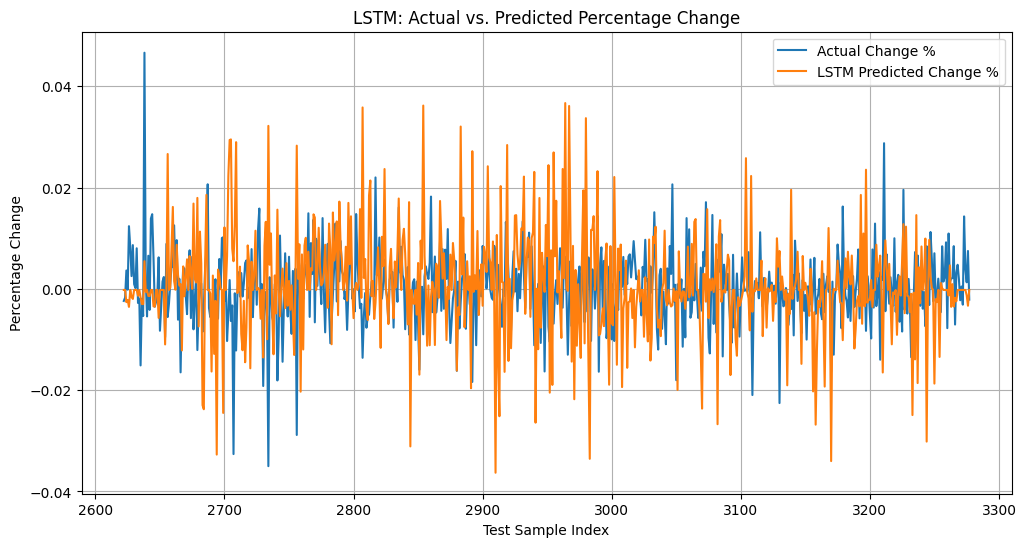

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(test["Pct_Change"], label="Actual Change %")
plt.plot(test["pred_change"], label="LSTM Predicted Change %")
plt.title("LSTM: Actual vs. Predicted Percentage Change")
plt.xlabel("Test Sample Index")
plt.ylabel("Percentage Change")
plt.legend()
plt.grid(True)
plt.show()